<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-2026-team-eda?scriptVersionId=329204185" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/swaptr/fifa-wc-2026-teams/teams.csv


## Loading dataset

In [2]:
df  = pd.read_csv("/kaggle/input/datasets/swaptr/fifa-wc-2026-teams/teams.csv")

In [3]:
df.head()

,team,team_country,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,...,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
0,Algeria,Algeria,16,27.2,52.0,1,11,90,1.0,0,...,1,0,0,1,100.0,0,0,0,0,NaN
1,Argentina,Argentina,16,29.4,48.0,1,11,90,1.0,3,...,0,0,1,0,0.0,0,0,0,0,NaN
2,Australia,Australia,18,25.4,33.0,2,22,180,2.0,2,...,1,0,1,1,50.0,0,0,0,0,NaN
3,Austria,Austria,16,29.2,63.0,1,11,90,1.0,2,...,0,0,1,0,0.0,1,1,0,0,0.0
4,Belgium,Belgium,16,29.6,54.0,1,11,90,1.0,0,...,0,1,0,0,0.0,0,0,0,0,NaN


In [4]:
df.tail()

,team,team_country,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,...,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
43,Tunisia,Tunisia,16,27.7,51.0,1,11,90,1.0,1,...,1,0,0,0,0.0,0,0,0,0,NaN
44,Türkiye,Turkey,18,27.2,75.5,2,22,180,2.0,0,...,2,0,0,2,100.0,0,0,0,0,NaN
45,United States,United States,18,27.1,63.5,2,22,180,2.0,4,...,0,0,2,0,0.0,0,0,0,0,NaN
46,Uruguay,Uruguay,16,29.2,67.0,1,11,90,1.0,1,...,0,1,0,0,0.0,0,0,0,0,NaN
47,Uzbekistan,Uzbekistan,16,27.8,39.0,1,11,90,1.0,1,...,1,0,0,0,0.0,0,0,0,0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Columns: 136 entries, team to gk_pens_save_pct_against
dtypes: float64(42), int64(92), object(2)
memory usage: 51.1+ KB


In [6]:
df.describe()

,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,...,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.0,48.0,5.0
mean,16.750000,28.300000,50.041667,1.333333,14.666667,120.000000,1.333333,1.875000,1.312500,3.187500,...,0.458333,0.416667,0.458333,0.291667,19.791667,0.125000,0.125000,0.0,0.0,0.0
std,1.816004,1.338306,13.109942,0.476393,5.240324,42.875376,0.476393,1.619364,1.257425,2.787939,...,0.581939,0.498224,0.581939,0.544150,36.814057,0.392754,0.392754,0.0,0.0,0.0
min,13.000000,25.400000,25.000000,1.000000,11.000000,90.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
25%,16.000000,27.275000,39.000000,1.000000,11.000000,90.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
50%,16.000000,28.200000,51.000000,1.000000,11.000000,90.000000,1.000000,1.500000,1.000000,2.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
75%,18.000000,29.225000,60.250000,2.000000,22.000000,180.000000,2.000000,2.250000,2.000000,4.250000,...,1.000000,1.000000,1.000000,0.250000,12.500000,0.000000,0.000000,0.0,0.0,0.0
max,22.000000,31.900000,75.500000,2.000000,22.000000,180.000000,2.000000,7.000000,6.000000,13.000000,...,2.000000,1.000000,2.000000,2.000000,100.000000,2.000000,2.000000,0.0,0.0,0.0


In [7]:
df.isnull().sum()

team                         0
team_country                 0
players_used                 0
avg_age                      0
possession                   0
                            ..
gk_pens_att_against          0
gk_pens_allowed_against      0
gk_pens_saved_against        0
gk_pens_missed_against       0
gk_pens_save_pct_against    43
Length: 136, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

team                         object
team_country                 object
players_used                  int64
avg_age                     float64
possession                  float64
                             ...   
gk_pens_att_against           int64
gk_pens_allowed_against       int64
gk_pens_saved_against         int64
gk_pens_missed_against        int64
gk_pens_save_pct_against    float64
Length: 136, dtype: object

In [10]:
df.shape

(48, 136)

In [11]:
df.columns

Index(['team', 'team_country', 'players_used', 'avg_age', 'possession',
       'games', 'games_starts', 'minutes', 'minutes_90s', 'goals',
       ...
       'gk_wins_against', 'gk_ties_against', 'gk_losses_against',
       'gk_clean_sheets_against', 'gk_clean_sheets_pct_against',
       'gk_pens_att_against', 'gk_pens_allowed_against',
       'gk_pens_saved_against', 'gk_pens_missed_against',
       'gk_pens_save_pct_against'],
      dtype='object', length=136)

In [12]:
df.nunique()

team                        48
team_country                48
players_used                10
avg_age                     32
possession                  31
                            ..
gk_pens_att_against          3
gk_pens_allowed_against      3
gk_pens_saved_against        1
gk_pens_missed_against       1
gk_pens_save_pct_against     1
Length: 136, dtype: int64

## EDA

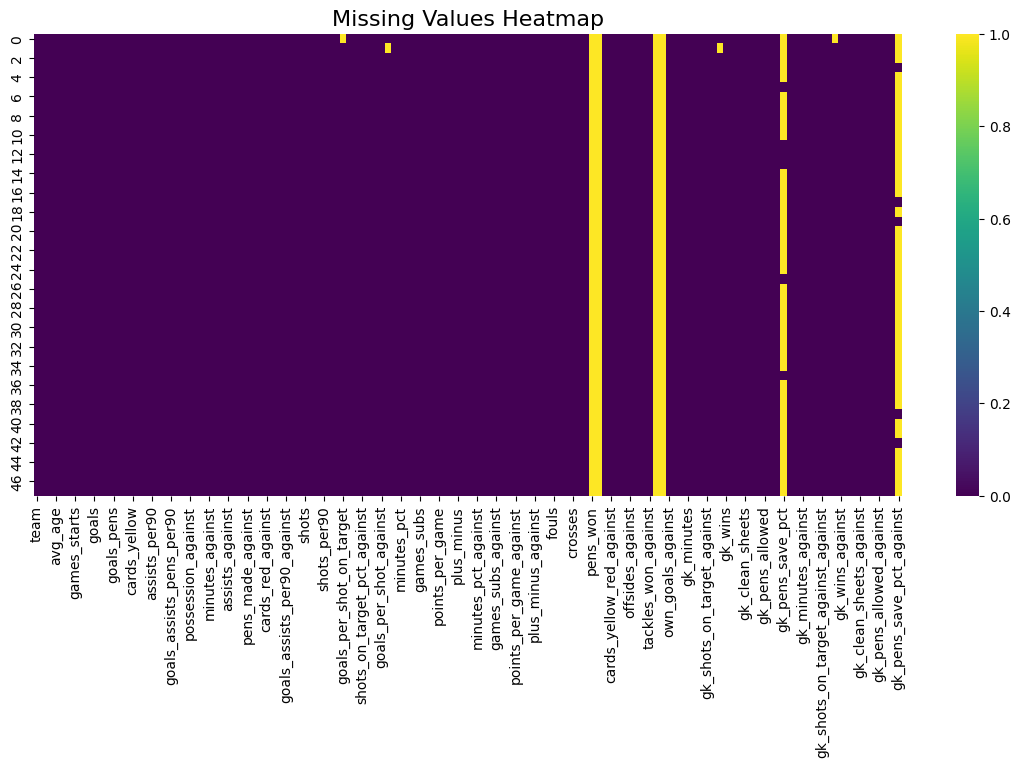

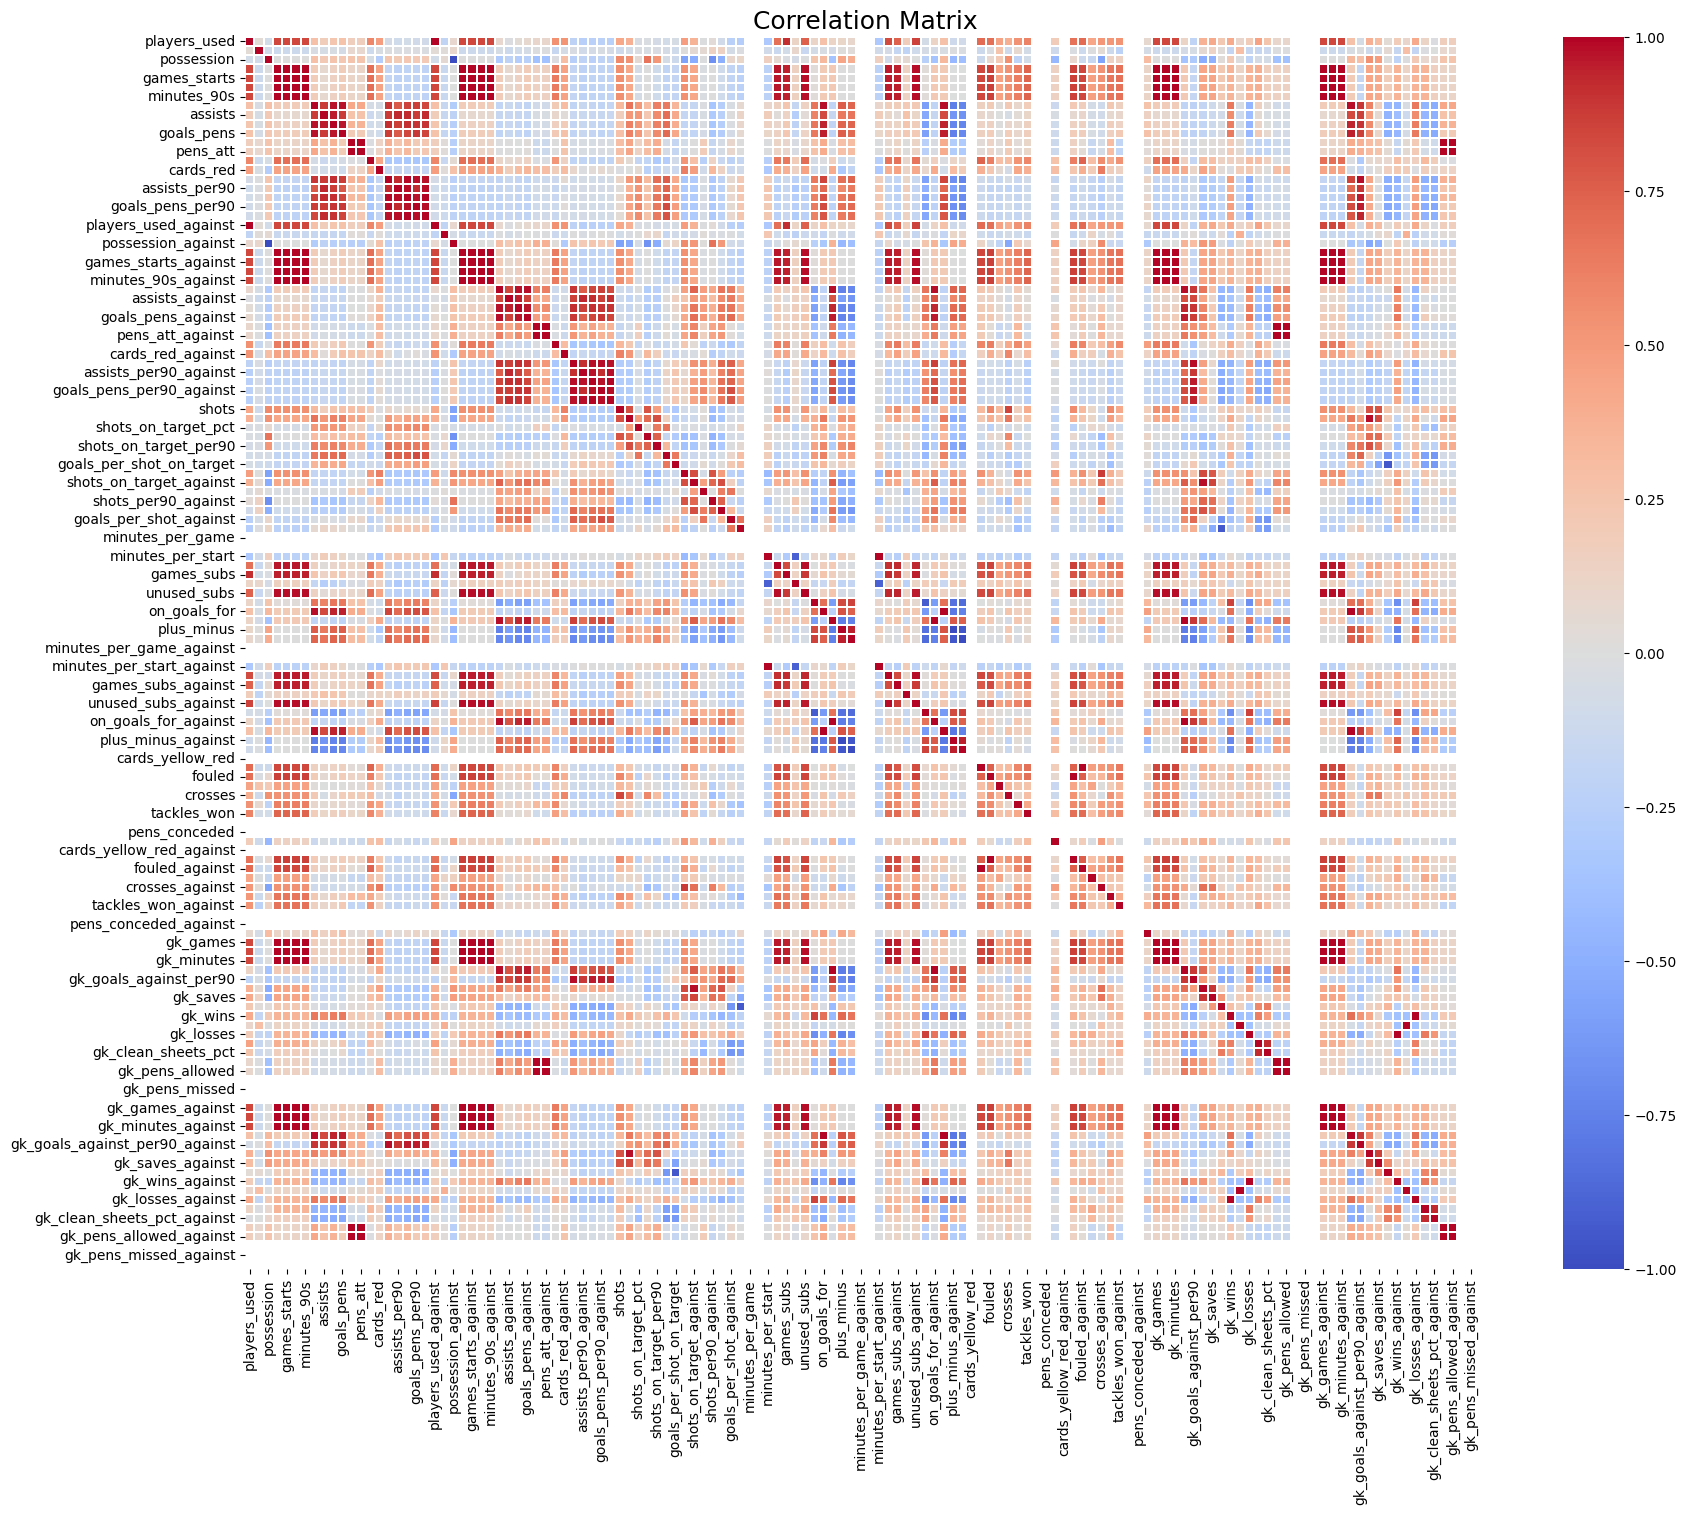

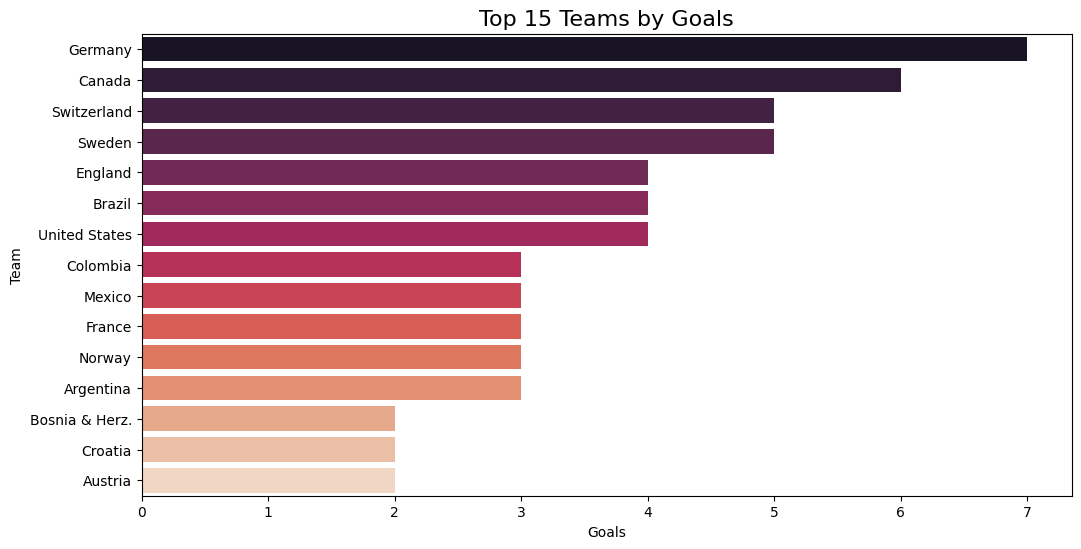

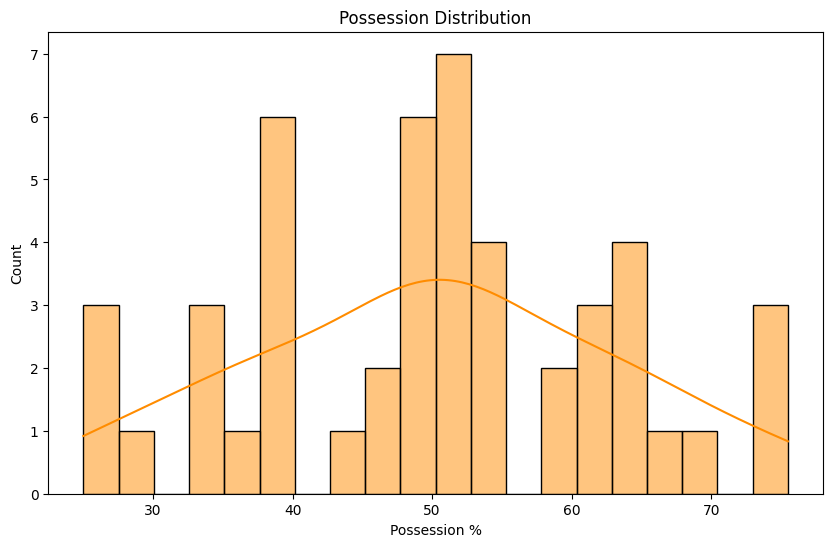

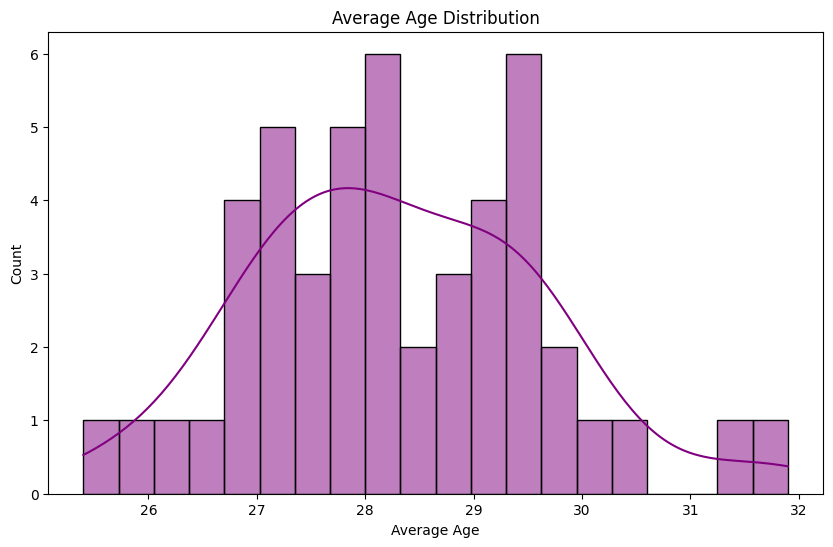

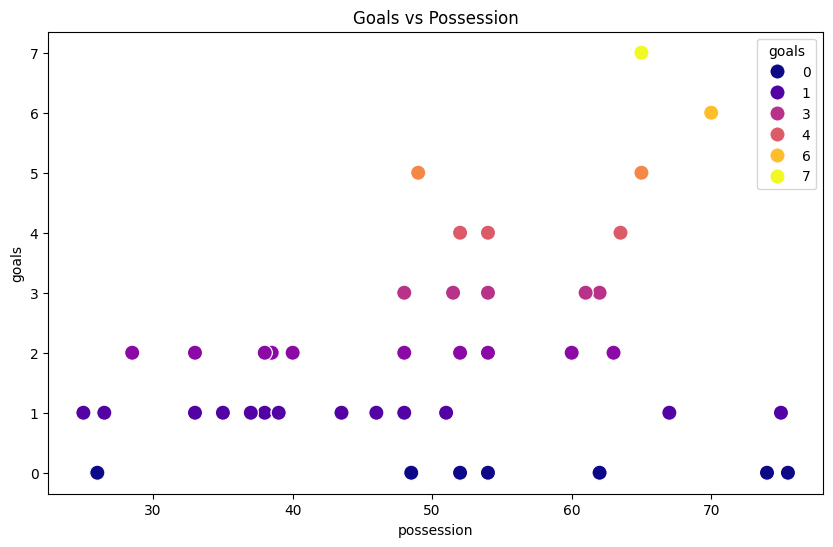

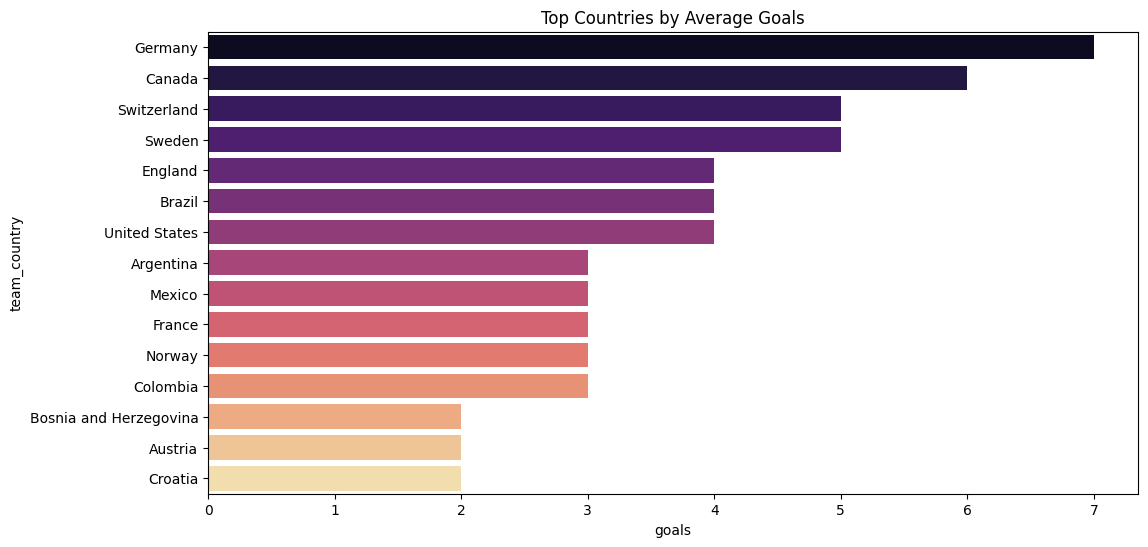

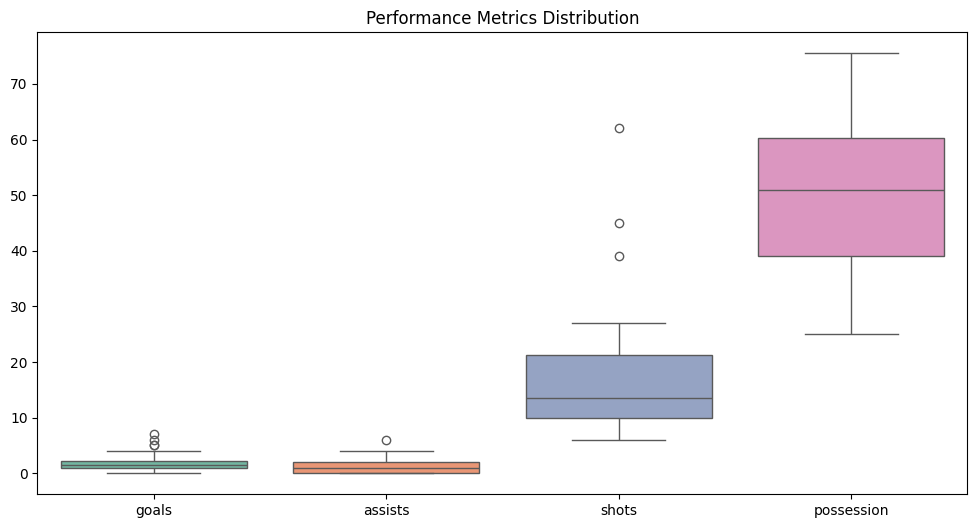

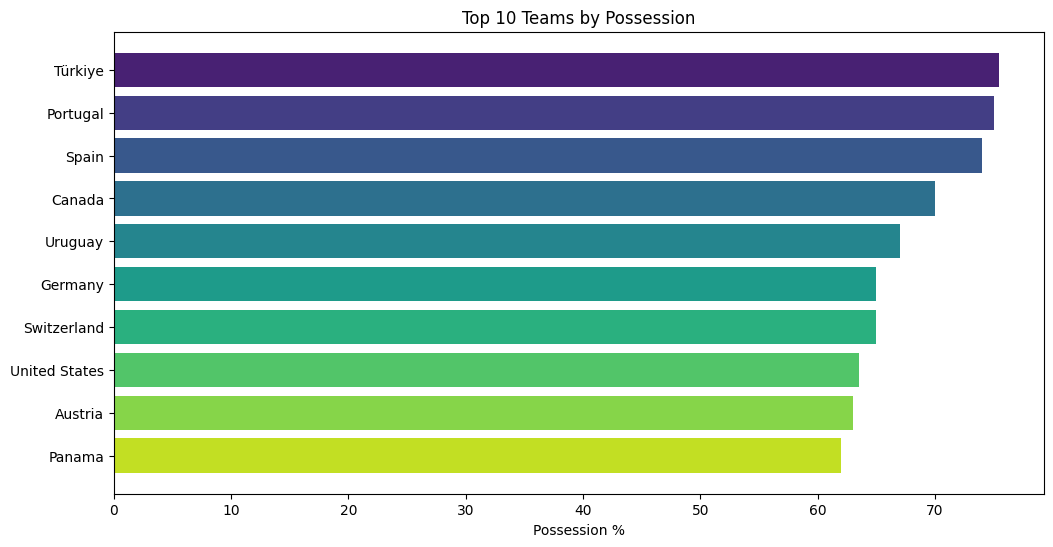

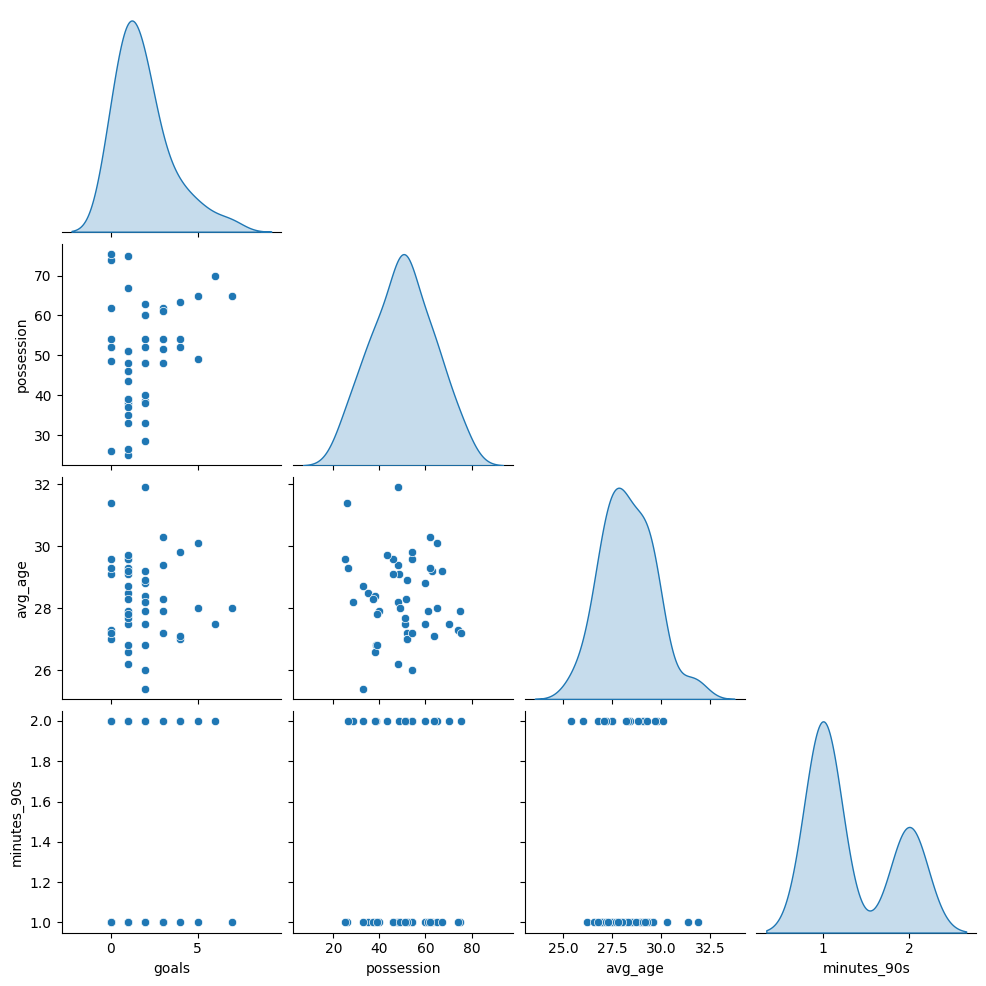

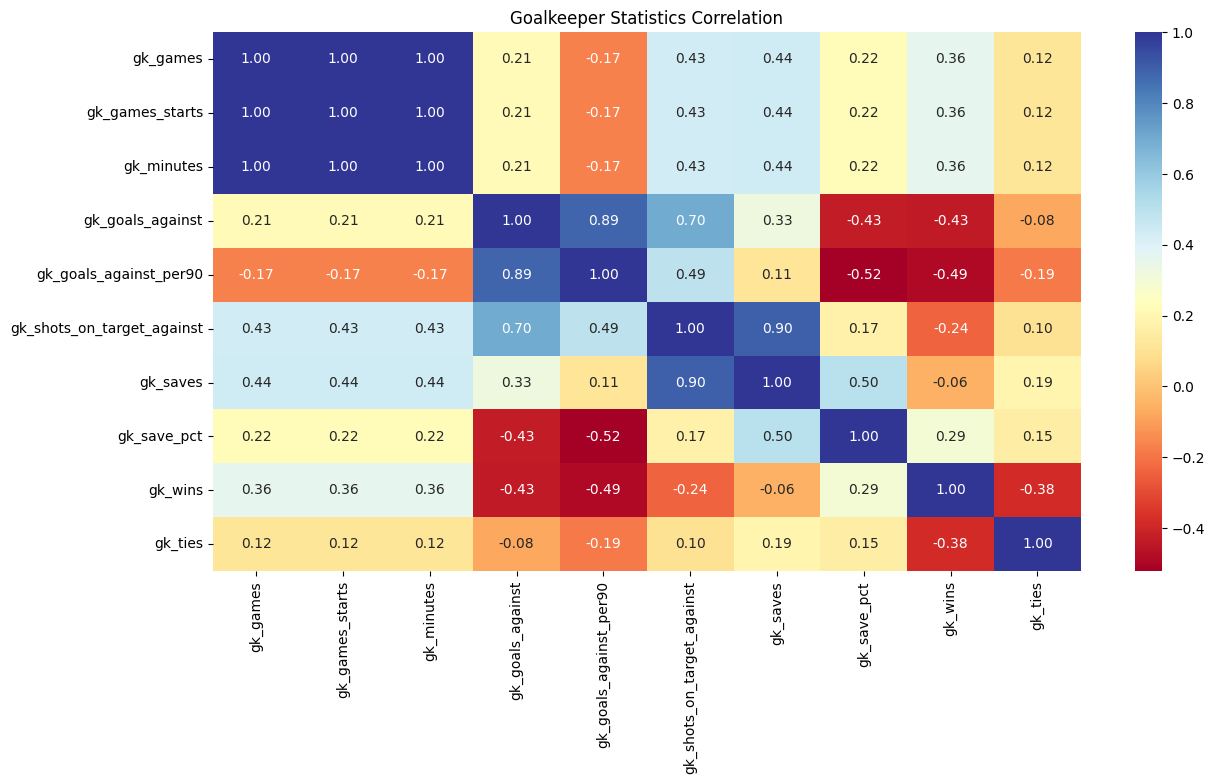

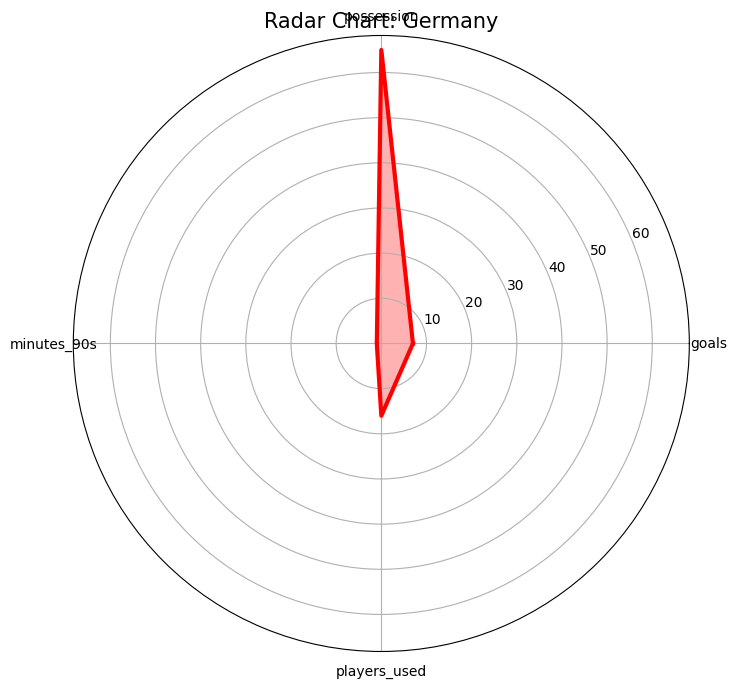

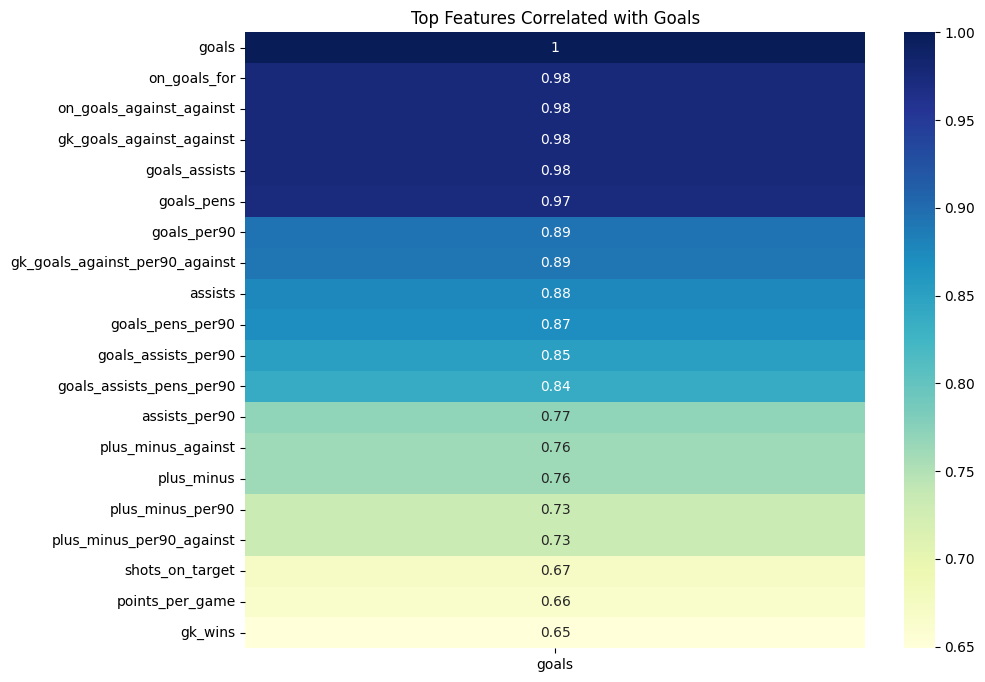

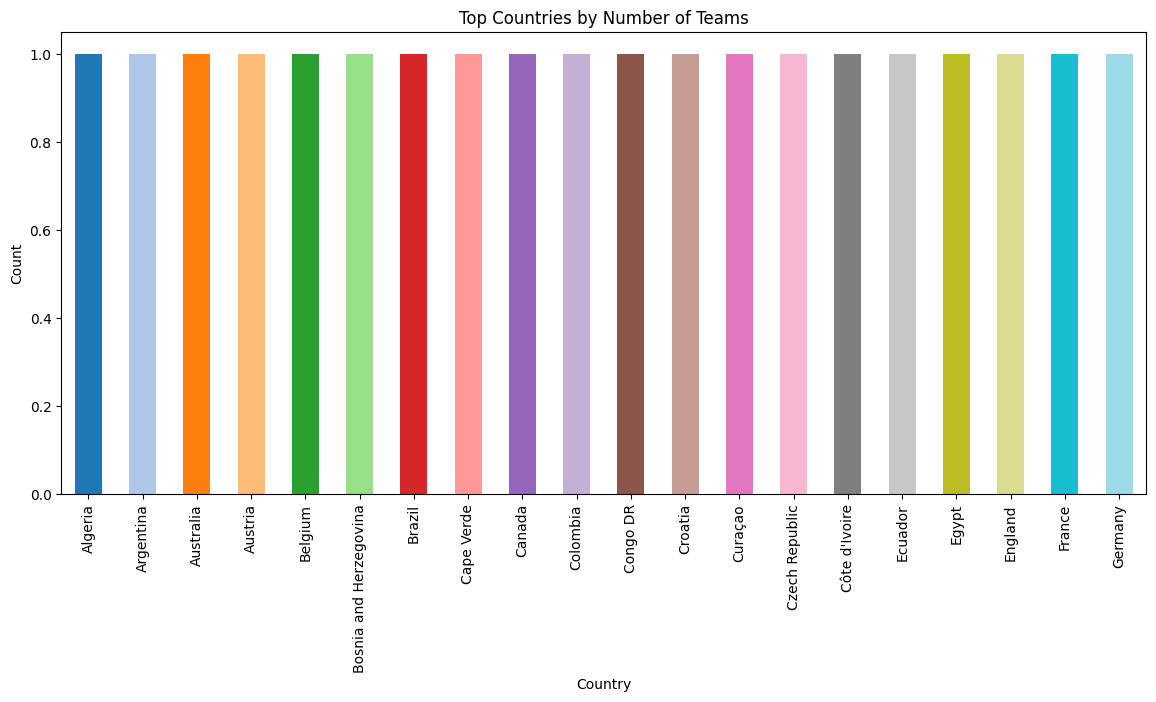

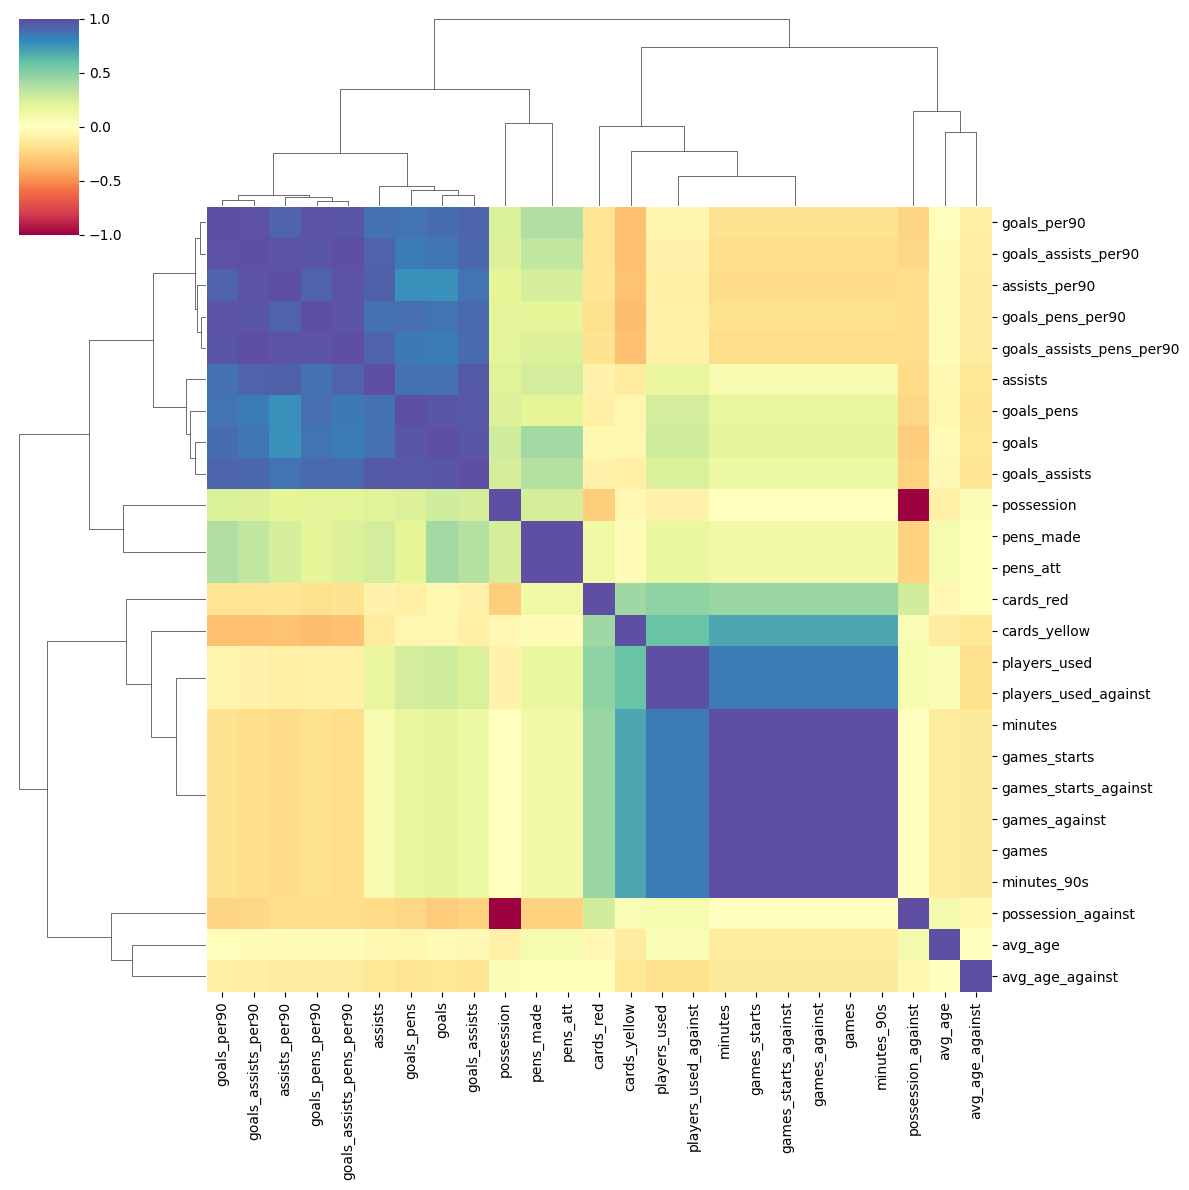

All advanced football visualizations completed successfully.


In [13]:
# ---------------------------
# Numeric Columns
# ---------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

# ==========================================================
# 1. MISSING VALUES HEATMAP
# ==========================================================
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis")
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

# ==========================================================
# 2. CORRELATION MATRIX
# ==========================================================
plt.figure(figsize=(20,16))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.1
)

plt.title("Correlation Matrix", fontsize=18)
plt.show()

# ==========================================================
# 3. TOP 15 TEAMS BY GOALS
# ==========================================================
if "goals" in df.columns:

    top_goals = df.sort_values(
        "goals",
        ascending=False
    ).head(15)

    plt.figure(figsize=(12,6))

    sns.barplot(
        data=top_goals,
        x="goals",
        y="team",
        palette="rocket"
    )

    plt.title("Top 15 Teams by Goals", fontsize=16)
    plt.xlabel("Goals")
    plt.ylabel("Team")

    plt.show()

# ==========================================================
# 4. POSSESSION DISTRIBUTION
# ==========================================================
if "possession" in df.columns:

    plt.figure(figsize=(10,6))

    sns.histplot(
        df["possession"],
        bins=20,
        kde=True,
        color="darkorange"
    )

    plt.title("Possession Distribution")
    plt.xlabel("Possession %")

    plt.show()

# ==========================================================
# 5. AGE DISTRIBUTION
# ==========================================================
if "avg_age" in df.columns:

    plt.figure(figsize=(10,6))

    sns.histplot(
        df["avg_age"],
        bins=20,
        kde=True,
        color="purple"
    )

    plt.title("Average Age Distribution")
    plt.xlabel("Average Age")

    plt.show()

# ==========================================================
# 6. GOALS vs POSSESSION
# ==========================================================
if "goals" in df.columns and "possession" in df.columns:

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=df,
        x="possession",
        y="goals",
        hue="goals",
        palette="plasma",
        s=120
    )

    plt.title("Goals vs Possession")
    plt.show()

# ==========================================================
# 7. TOP COUNTRIES BY AVERAGE GOALS
# ==========================================================
if "team_country" in df.columns and "goals" in df.columns:

    country_goals = (
        df.groupby("team_country")["goals"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )

    plt.figure(figsize=(12,6))

    sns.barplot(
        data=country_goals,
        x="goals",
        y="team_country",
        palette="magma"
    )

    plt.title("Top Countries by Average Goals")
    plt.show()

# ==========================================================
# 8. BOXPLOT OF KEY PERFORMANCE METRICS
# ==========================================================
key_cols = [
    col for col in
    ["goals","assists","shots","possession"]
    if col in df.columns
]

if len(key_cols) > 0:

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df[key_cols],
        palette="Set2"
    )

    plt.title("Performance Metrics Distribution")

    plt.show()

# ==========================================================
# 9. TOP 10 TEAMS BY POSSESSION
# ==========================================================
if "possession" in df.columns:

    top_poss = df.sort_values(
        "possession",
        ascending=False
    ).head(10)

    plt.figure(figsize=(12,6))

    colors = sns.color_palette("viridis", len(top_poss))

    plt.barh(
        top_poss["team"],
        top_poss["possession"],
        color=colors
    )

    plt.title("Top 10 Teams by Possession")
    plt.xlabel("Possession %")
    plt.gca().invert_yaxis()

    plt.show()

# ==========================================================
# 10. PAIRPLOT FOR IMPORTANT FEATURES
# ==========================================================
important_cols = [
    col for col in
    ["goals","possession","avg_age","minutes_90s"]
    if col in df.columns
]

if len(important_cols) >= 2:

    sns.pairplot(
        df[important_cols],
        corner=True,
        diag_kind="kde",
        palette="husl"
    )

    plt.show()

# ==========================================================
# 11. GOALKEEPER ANALYSIS
# ==========================================================
gk_cols = [
    c for c in df.columns
    if c.startswith("gk_")
]

if len(gk_cols) > 0:

    top_gk = gk_cols[:10]

    plt.figure(figsize=(14,7))

    sns.heatmap(
        df[top_gk].corr(),
        annot=True,
        cmap="RdYlBu",
        fmt=".2f"
    )

    plt.title("Goalkeeper Statistics Correlation")

    plt.show()

# ==========================================================
# 12. RADAR CHART FOR TOP TEAM
# ==========================================================
radar_features = [
    col for col in
    ["goals","possession","minutes_90s","players_used"]
    if col in df.columns
]

if len(radar_features) >= 3:

    team_data = (
        df.sort_values("goals", ascending=False)
        .iloc[0]
    )

    values = team_data[radar_features].values.tolist()

    values += values[:1]

    angles = np.linspace(
        0,
        2*np.pi,
        len(radar_features),
        endpoint=False
    ).tolist()

    angles += angles[:1]

    fig = plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    ax.plot(
        angles,
        values,
        linewidth=3,
        color="red"
    )

    ax.fill(
        angles,
        values,
        alpha=0.3,
        color="red"
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features)

    plt.title(
        f"Radar Chart: {team_data['team']}",
        size=15
    )

    plt.show()

# ==========================================================
# 13. FEATURE IMPORTANCE STYLE HEATMAP
# ==========================================================
top_corr = (
    corr["goals"]
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pd.DataFrame(top_corr),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Top Features Correlated with Goals")

plt.show()

# ==========================================================
# 14. COUNTRY-WISE TEAM COUNT
# ==========================================================
if "team_country" in df.columns:

    plt.figure(figsize=(14,6))

    df["team_country"].value_counts().head(20).plot(
        kind="bar",
        color=sns.color_palette("tab20")
    )

    plt.title("Top Countries by Number of Teams")
    plt.xlabel("Country")
    plt.ylabel("Count")

    plt.show()

# ==========================================================
# 15. CLUSTERED HEATMAP
# ==========================================================
sample_cols = numeric_cols[:25]

sns.clustermap(
    df[sample_cols].corr(),
    cmap="Spectral",
    figsize=(12,12)
)

plt.show()

print("All advanced football visualizations completed successfully.")

## Feature engineering

In [14]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

Dataset Shape: (48, 136)

Target Distribution:
goal_class
0    24
1    24
Name: count, dtype: int64

Train Shape: (38, 132)
Test Shape : (10, 132)

Numeric Features: 130
Categorical Features: 2


Logistic Regression

Accuracy : 0.9
Precision: 0.8333
Recall   : 1.0
F1 Score : 0.9091
ROC AUC  : 0.96
CV Score : 0.975

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



Decision Tree

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
CV Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                          

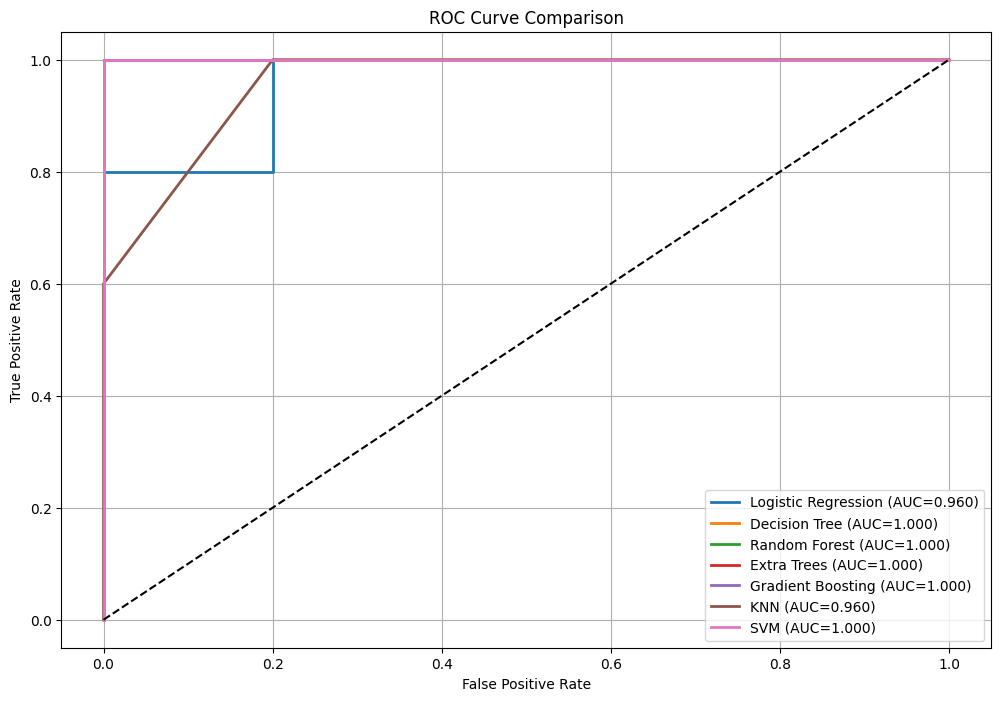



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC  \
1        Decision Tree       1.0   1.000000     1.0  1.000000     1.00   
2        Random Forest       1.0   1.000000     1.0  1.000000     1.00   
3          Extra Trees       1.0   1.000000     1.0  1.000000     1.00   
6                  SVM       0.9   0.833333     1.0  0.909091     1.00   
4    Gradient Boosting       1.0   1.000000     1.0  1.000000     1.00   
0  Logistic Regression       0.9   0.833333     1.0  0.909091     0.96   
5                  KNN       0.9   0.833333     1.0  0.909091     0.96   

   CV Accuracy  
1     1.000000  
2     1.000000  
3     0.971429  
6     0.896429  
4     1.000000  
0     0.975000  
5     0.792857  


BEST MODEL
Best Model : Decision Tree
Best ROC AUC: 1.0


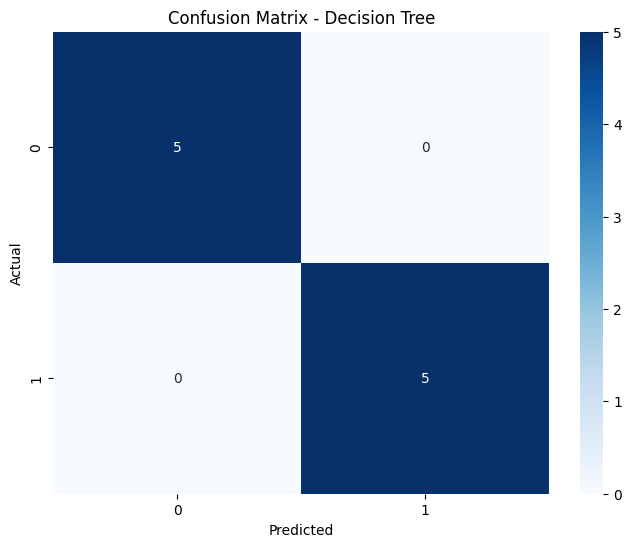



FINAL SUMMARY
Rows: 48
Columns: 137

Best Performing Model: Decision Tree

Top 5 Models:
               Model  Accuracy  ROC AUC
1      Decision Tree       1.0      1.0
2      Random Forest       1.0      1.0
3        Extra Trees       1.0      1.0
6                SVM       0.9      1.0
4  Gradient Boosting       1.0      1.0

Pipeline Completed Successfully.


In [15]:
print("Dataset Shape:", df.shape)


df["goal_class"] = (
    df["goals"] >
    df["goals"].median()
).astype(int)

# ==========================================================
# REMOVE DATA LEAKAGE
# ==========================================================

leakage_cols = [
    "goal_class",
    "goals",
    "goals_per90",
    "goals_assists_per90",
    "goals_assists_pens_per90"
]

existing_cols = [
    col
    for col in leakage_cols
    if col in df.columns
]

X = df.drop(columns=existing_cols)

y = df["goal_class"]

print("\nTarget Distribution:")
print(y.value_counts())

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================================================
# FEATURE TYPES
# ==========================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns

print("\nNumeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=500,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

# ==========================================================
# TRAINING
# ==========================================================

results = []

best_auc = 0
best_pipeline = None
best_name = ""

plt.figure(figsize=(12,8))

for name, model in models.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # TRAIN
    pipeline.fit(
        X_train,
        y_train
    )

    # PREDICTIONS
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(
        X_test
    )[:,1]

    # METRICS
    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred
    )

    rec = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    print("\nAccuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(auc,4))
    print("CV Score :", round(cv,4))

    print("\nClassification Report\n")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        auc,
        cv
    ])

    # ROC CURVE
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

    if auc > best_auc:
        best_auc = auc
        best_pipeline = pipeline
        best_name = name

# ==========================================================
# ROC CURVE
# ==========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "CV Accuracy"
    ]
)

results_df = results_df.sort_values(
    "ROC AUC",
    ascending=False
)

print("\n")
print("="*90)
print("MODEL COMPARISON")
print("="*90)

print(results_df)

# ==========================================================
# BEST MODEL
# ==========================================================

print("\n")
print("="*90)
print("BEST MODEL")
print("="*90)

print("Best Model :", best_name)
print("Best ROC AUC:", round(best_auc,4))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

best_pred = best_pipeline.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# (TREE MODELS ONLY)
# ==========================================================

if best_name in [
    "Random Forest",
    "Extra Trees"
]:

    feature_names = (
        best_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    importances = (
        best_pipeline.named_steps[
            "model"
        ].feature_importances_
    )

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(25)
    )

    plt.figure(figsize=(12,10))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 25 Important Features ({best_name})"
    )

    plt.show()

    print("\nTop Features:\n")
    print(importance_df.head(25))

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n")
print("="*90)
print("FINAL SUMMARY")
print("="*90)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nBest Performing Model:", best_name)

print("\nTop 5 Models:")
print(
    results_df[
        ["Model","Accuracy","ROC AUC"]
    ].head()
)

print("\nPipeline Completed Successfully.")

## Thank you...pls upvote!!!!!!!!!!!!!1